# Description for the test case
Flat plate suddenly accelerated inside a static laminar newtonian incompresible ideal flow with constant propierties

## Goberning equations
$$ \nabla \vec{u}=0$$
$$ \frac{\partial \vec{u}}{\partial t} + (\vec{u}\nabla \vec{u}) = -\nabla p + \frac{1}{Re} \nabla^2\vec{u} $$
$$ \frac{\partial T}{\partial t} + (\vec{u}\nabla T) = \frac{1}{RePr} \nabla^2T \frac{Ec}{Re}\phi $$
$$ \phi = 2\left[ \left( \frac{\partial u}{\partial x}\right)^2 + \left( \frac{\partial v}{\partial y}\right)^2\right] + \left[ \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x}\right]^2 $$

## Finite difference simulation:

Estructure PISO: (first we resolve the velocity components evoulution neglecting the pressure effects, and later we correct them)

$$ u_{i,j}^* = u_{i,j}^n + \Delta t \left[ -\left( u\partial_x u + v \partial_y u \right)_{i,j} + \frac{1}{Re} \nabla^2u_{i,j} \right]$$
$$ v_{i,j}^* = v_{i,j}^n + \Delta t \left[ -\left( u\partial_x v + v \partial_y v \right)_{i,j} + \frac{1}{Re} \nabla^2v_{i,j} \right]$$

Poisson equation for pressure:

$$ \nabla^2p_{i,j}^{n+1} = \frac{1}{\Delta t} \left[ \frac{u_{i,j+1}^{n+1} - u_{i,j-1}^n}{2\Delta x} + \frac{v_{i,j+1}^{n+1} - v_{i,j-1}^n}{2\Delta y} \right]$$

$$ u_{i,j}^{n+1} = u_{i,j}^* - \Delta t \frac{p_{i,j+1}^{n+1} - p_{i,j-1}^{n+1}}{2\Delta x} $$
$$ v_{i,j}^{n+1} = v_{i,j}^* - \Delta t \frac{p_{i+1,j}^{n+1} - p_{i-1,j}^{n+1}}{2\Delta x} $$

Energy equation:

$$ T_{i,j}^{n+1} = T_{i,j}^n + \Delta t \left[ -\left( u\partial_x T + v \partial_y T \right)_{i,j} + \frac{1}{RePr} \nabla^2 T_{i,j} + \frac{Ec}{Re} \phi_{i,j}\right]$$


Boundary conditions:

$$ \vec{u}|_{y=0,L}=0 $$
$$ u|_{x=-2} = u|_{x=-1} $$
$$ p|_{x=0} = p|_{x=1} $$
$$ p|_{y=0} = p|_{y=1} $$
$$ p|_{x=-2} = p|_{x=-1} $$

## Aditional surmises:

No slip condition in the surface of the plate
Gravitational effects neglected


# ROM + Data Assimilation: Nudging, Kalman, EnKF, 4DVar

In this notebook we study **data assimilation (DA)** methods for flow reconstruction
using a **reduced-order model (ROM)**.

We will use a *synthetic* 2D flow that mimics a **suddenly accelerated flat plate**
inside a channel at high Reynolds number. The details of the CFD are not important here;
instead, we represent the flow using a few spatial modes and time-dependent amplitudes.

We will compare four DA strategies in **reduced space**:

- **Nudging**
- **Kalman Filter (KF)**
- **Ensemble Kalman Filter (EnKF)**
- **4DVar** (on a short time window)

The students are encouraged to:
- change **observation noise** (R), **model error** (B),
- change **nudging gain**, **ensemble size**, **4DVar window length**,
- and observe how the reconstruction and the error evolve.


In [22]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from IPython.display import display, HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

set_num_threads(14)  # Ajusta al nº de núcleos que quieras

In [23]:
# ============================
# 1) Synthetic "truth" flow
# ============================

# Grid for visualization (small to keep it light)
Nx, Ny = 40, 20
x = np.linspace(0, 2.0, Nx)
y = np.linspace(0, 1.0, Ny)
X, Y = np.meshgrid(x, y, indexing="ij")
n_state = Nx * Ny

# Define 4 spatial modes (you can tweak shapes to taste)
def mode_base_flow(X, Y):
    # Poiseuille-like profile
    return (4 * Y * (1 - Y))

def mode_separation_bubble(X, Y):
    # Localized structure near plate (right half)
    cx, cy = 1.5, 0.2
    sigma_x, sigma_y = 0.2, 0.1
    return np.exp(-((X - cx)**2 / sigma_x**2 + (Y - cy)**2 / sigma_y**2))

def mode_shear_layer(X, Y):
    return np.sin(2 * np.pi * X) * np.exp(-((Y - 0.3)**2) / 0.05)

def mode_wake(X, Y):
    return np.sin(3 * np.pi * (X - 1.0)) * (1 - Y) * (X > 1.0)

phi1 = mode_base_flow(X, Y)
phi2 = mode_separation_bubble(X, Y)
phi3 = mode_shear_layer(X, Y)
phi4 = mode_wake(X, Y)

# Stack and normalize modes
modes = np.stack([phi1, phi2, phi3, phi4], axis=-1)  # (Nx, Ny, 4)
modes_2d = modes.reshape(n_state, 4)

# Normalize each mode to unit L2 norm
for j in range(4):
    norm = np.linalg.norm(modes_2d[:, j])
    modes_2d[:, j] /= norm

# Time axis
n_steps = 200
dt = 0.05
t = np.arange(n_steps) * dt

# Define "true" modal coefficients a_true(t).
# We mimic an impulsive start at t ~ 1, growth and some oscillations.
def coeffs_truth(t):
    a1 = 1.0 - np.exp(-2.0 * np.maximum(t - 0.5, 0))        # base flow builds up
    a2 = 0.8 * np.exp(-0.5 * np.maximum(t - 2.0, 0))        # separation bubble decays
    a3 = 0.5 * np.sin(2 * np.pi * 0.5 * t) * (t > 1.0)      # shear oscillation
    a4 = 0.6 * np.sin(2 * np.pi * 0.2 * t + 0.5) * (t > 1.5)  # wake-like oscillation
    return np.vstack([a1, a2, a3, a4])  # shape (4, n_steps)

a_true = coeffs_truth(t)  # (4, n_steps)

# Build full-state truth snapshots
snapshots_truth = modes_2d @ a_true   # (n_state, n_steps)


In [24]:
# ============================
# 2) Build ROM from modal time series
# ============================

# True reduced state is a_true; we fit a linear model r_{k+1} = F r_k
X = a_true[:, :-1]   # (4, n_steps-1)
Xp = a_true[:, 1:]   # (4, n_steps-1)

# Least-squares estimate of F
F_est = Xp @ X.T @ np.linalg.inv(X @ X.T)  # (4, 4)

# Slightly perturb F to introduce model error (optional)
F_model = F_est.copy()
F_model[2, 2] *= 0.98
F_model[3, 3] *= 1.02

print("F_model:\n", F_model)

# For convenience, define reconstruction operator Phi
Phi = modes_2d  # (n_state, 4)
r_true = a_true  # rename for clarity


F_model:
 [[ 9.95855315e-01  2.56917629e-02 -1.34573722e-03  2.03939462e-03]
 [-3.10029087e-03  9.95512136e-01 -3.74255799e-03  2.87348371e-03]
 [ 3.98530476e-04  1.81124804e-03  9.69407404e-01  1.27761981e-02]
 [ 3.04602947e-03 -9.45852567e-03 -1.65835176e-02  1.01535416e+00]]


In [25]:
# ============================
# 3) Observation operator (sensors)
# ============================

# Choose a few sensor locations on the lower wall (y ~ 0) and in the wake
sensor_coords = [
    (int(0.4 * Nx), 1),
    (int(0.8 * Nx), 1),
    (int(1.3 / 2.0 * Nx), 1),          # near bubble
    (int(1.7 / 2.0 * Nx), int(0.5 * Ny)),  # in shear layer
]

sensor_indices = []
for (ix, iy) in sensor_coords:
    idx = ix * Ny + iy
    sensor_indices.append(idx)

sensor_indices = np.array(sensor_indices, dtype=int)
n_sensors = len(sensor_indices)
print("Sensor indices:", sensor_indices)

# Observation matrix in physical space
H_x = np.zeros((n_sensors, n_state))
for j, idx in enumerate(sensor_indices):
    H_x[j, idx] = 1.0

# Observation matrix in reduced space
H_tilde = H_x @ Phi    # (n_sensors, 4)


# ============================
# 4) Helper functions
# ============================

def reconstruct_field(r):
    """Reconstruct full state from reduced state r."""
    return Phi @ r  # (n_state,)

def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def plot_snapshot(state_vec, title=""):
    """Plot 2D snapshot from flat state vector."""
    field = state_vec.reshape(Nx, Ny)
    Xg, Yg = np.meshgrid(x, y, indexing="ij")  # <-- usar siempre la malla correcta aquí
    plt.figure(figsize=(10, 6))
    plt.contourf(Xg, Yg, field, levels=30)
    plt.colorbar()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.tight_layout()
    plt.show()



Sensor indices: [321 641 521 690]


# 5) Data assimilation clases

## nudging

In [26]:
# ============================
# 5) Data assimilation classes
# ============================

class NudgingAssimilator:
    def __init__(self, F, H_tilde, gamma=0.2):
        """
        F: (n_r, n_r) reduced propagator
        H_tilde: (n_sensors, n_r) observation in reduced space
        gamma: nudging gain
        """
        self.F = F
        self.H = H_tilde
        self.gamma = gamma

    def step(self, r_prev, y_obs):
        # Model forecast
        r_pred = self.F @ r_prev
        # Innovation
        y_pred = self.H @ r_pred
        innovation = y_obs - y_pred
        # Nudging correction
        r_upd = r_pred + self.gamma * (self.H.T @ innovation)
        return r_upd


## Kalman filter

In [27]:
class KalmanAssimilator:
    def __init__(self, F, H_tilde, b_std=1e-3, r_std=0.05):
        """
        F: (n_r, n_r)
        H_tilde: (n_sensors, n_r)
        b_std: process noise std
        r_std: observation noise std
        """
        self.F = F
        self.H = H_tilde
        n_r = F.shape[0]
        n_s = H_tilde.shape[0]

        self.B = (b_std**2) * np.eye(n_r)
        self.R = (r_std**2) * np.eye(n_s)
        self.P = np.eye(n_r) * 1.0
        self.I = np.eye(n_r)

    def step(self, r_prev, y_obs):
        # Predict
        r_pred = self.F @ r_prev
        P_pred = self.F @ self.P @ self.F.T + self.B

        # Update
        y_pred = self.H @ r_pred
        S = self.H @ P_pred @ self.H.T + self.R
        K = P_pred @ self.H.T @ np.linalg.inv(S)

        innovation = y_obs - y_pred
        r_upd = r_pred + K @ innovation
        self.P = (self.I - K @ self.H) @ P_pred

        return r_upd


## Ensemble Kalman filter

In [28]:
class EnKFAssimilator:
    def __init__(self, F, H_tilde, n_ens=30, b_std=1e-3, r_std=0.05):
        """
        F: (n_r, n_r)
        H_tilde: (n_sensors, n_r)
        n_ens: ensemble size
        """
        self.F = F
        self.H = H_tilde
        self.n_ens = n_ens
        self.b_std = b_std
        self.r_std = r_std

        n_r = F.shape[0]
        self.R = (r_std**2) * np.eye(H_tilde.shape[0])

        # Initialize ensemble around zero
        self.ensemble = 0.1 * np.random.randn(n_r, n_ens)

    def step(self, y_obs):
        n_r, n_ens = self.ensemble.shape
        n_s = self.H.shape[0]

        # Forecast: propagate each member + model noise
        for j in range(n_ens):
            self.ensemble[:, j] = self.F @ self.ensemble[:, j] + \
                                  self.b_std * np.random.randn(n_r)

        # Compute ensemble mean and anomalies
        r_mean = np.mean(self.ensemble, axis=1, keepdims=True)  # (n_r, 1)
        A = self.ensemble - r_mean                               # (n_r, n_ens)

        # Predicted observations
        Y = self.H @ self.ensemble                               # (n_s, n_ens)
        y_mean = np.mean(Y, axis=1, keepdims=True)               # (n_s, 1)
        Y_ano = Y - y_mean

        # Covariances in ensemble space
        Pf = (A @ A.T) / (n_ens - 1)                             # (n_r, n_r)
        Py = (Y_ano @ Y_ano.T) / (n_ens - 1) + self.R            # (n_s, n_s)
        K = Pf @ self.H.T @ np.linalg.inv(Py)                    # (n_r, n_s)

        # Perturbed observations
        y_pert = y_obs.reshape(-1, 1) + self.r_std * np.random.randn(n_s, n_ens)

        # Update each ensemble member
        self.ensemble = self.ensemble + K @ (y_pert - Y)

        # Return ensemble mean as analysis
        r_an = np.mean(self.ensemble, axis=1)
        return r_an


## 4DVar

In [29]:
class Var4DAssimilator:
    """
    Simple 4DVar on a single time window for the reduced model.

    We estimate the optimal initial reduced state r0 that fits
    the observations y_0,...,y_{N-1} under the model r_{k+1} = F r_k.
    """

    def __init__(self, F, H_tilde, b_std=0.1, r_std=0.05, window_size=20):
        self.F = F
        self.H = H_tilde
        self.n_r = F.shape[0]
        self.n_s = H_tilde.shape[0]
        self.N = window_size

        self.B = (b_std**2) * np.eye(self.n_r)
        self.R = (r_std**2) * np.eye(self.n_s)

    def build_H_stack(self):
        """Build the big observation operator H_stack such that y_stack = H_stack r0."""
        H_list = []
        F_power = np.eye(self.n_r)
        for k in range(self.N):
            H_list.append(self.H @ F_power)
            F_power = self.F @ F_power
        H_stack = np.vstack(H_list)  # (N * n_s, n_r)
        return H_stack

    def assimilate(self, r_b, y_window):
        """
        r_b: background guess for r0 (n_r,)
        y_window: (N, n_s) observations over the window
        Returns: r0_opt, and the trajectory r_k over the window
        """
        H_stack = self.build_H_stack()
        y_stack = y_window.reshape(-1)  # (N * n_s,)

        B_inv = np.linalg.inv(self.B)
        # Assume R = sigma^2 I → R_N^{-1} = (1/sigma^2) I
        sigma2 = self.R[0, 0]
        A = B_inv + (1.0 / sigma2) * (H_stack.T @ H_stack)
        b = B_inv @ r_b + (1.0 / sigma2) * (H_stack.T @ y_stack)

        r0_opt = np.linalg.solve(A, b)

        # Reconstruct trajectory r_k
        traj = []
        r_k = r0_opt.copy()
        for k in range(self.N):
            traj.append(r_k.copy())
            r_k = self.F @ r_k
        traj = np.array(traj)  # (N, n_r)
        return r0_opt, traj


In [30]:
# ============================
# 6) Experiment runner *sequential* data assimilation
# ============================

def run_sequential_DA(method="nudging",
                      gamma=0.2,
                      b_std=1e-3,
                      r_std=0.05,
                      n_ens=30,
                      obs_noise_std=0.05,
                      r0_perturb=0.5):
    """
    method: 'nudging', 'kalman', 'enkf' or 'none'
    """

    n_r = F_model.shape[0]
    n_steps_local = n_steps

    # Truth in reduced space
    r_truth = r_true  # (4, n_steps)

    # Observations from truth
    y_truth = H_tilde @ r_truth   # (n_sensors, n_steps)
    noise = obs_noise_std * np.random.randn(n_sensors, n_steps)
    y_obs = y_truth + noise

    # Initial guess for reduced state
    r0 = r_truth[:, 0] + r0_perturb * np.random.randn(n_r)

    # Initialize method
    if method == "nudging":
        assim = NudgingAssimilator(F_model, H_tilde, gamma=gamma)
        r_k = r0.copy()
        label = "Nudging"
    elif method == "kalman":
        assim = KalmanAssimilator(F_model, H_tilde, b_std=b_std, r_std=r_std)
        r_k = r0.copy()
        label = "Kalman"
    elif method == "enkf":
        assim = EnKFAssimilator(F_model, H_tilde, n_ens=n_ens,
                                b_std=b_std, r_std=r_std)
        # Use ensemble mean as starting point
        assim.ensemble += r0.reshape(-1, 1)
        r_k = np.mean(assim.ensemble, axis=1)
        label = "EnKF"
    elif method == "none":
        assim = None
        r_k = r0.copy()
        label = "Pure ROM"
    else:
        raise ValueError("Unknown method")

    # Storage
    r_hist = np.zeros((n_r, n_steps_local))
    r_hist[:, 0] = r_k
    err_hist = np.zeros(n_steps_local)

    # Loop
    for k in range(1, n_steps_local):
        if method == "none":
            # Pure forecast
            r_k = F_model @ r_k
        elif method in ("nudging", "kalman"):
            r_k = assim.step(r_k, y_obs[:, k])
        elif method == "enkf":
            r_k = assim.step(y_obs[:, k])

        r_hist[:, k] = r_k

        s_est = reconstruct_field(r_k)
        s_true_k = reconstruct_field(r_truth[:, k])
        err_hist[k] = rmse(s_est, s_true_k)

    # Error of pure ROM for comparison
    r_rom = np.zeros_like(r_hist)
    r_rom[:, 0] = r0.copy()
    err_rom = np.zeros(n_steps_local)
    r_k2 = r0.copy()
    for k in range(1, n_steps_local):
        r_k2 = F_model @ r_k2
        r_rom[:, k] = r_k2
        s_est = reconstruct_field(r_k2)
        s_true_k = reconstruct_field(r_truth[:, k])
        err_rom[k] = rmse(s_est, s_true_k)

    # Plot error
    plt.figure(figsize=(10, 6))
    plt.plot(err_rom, label="ROM only")
    if method != "none":
        plt.plot(err_hist, label=label)
    plt.xlabel("time step")
    plt.ylabel("RMSE")
    plt.title(f"Error comparison ({label})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Final snapshots
    plot_snapshot(reconstruct_field(r_truth[:, -1]),
                  title="Truth (final time)")
    if method != "none":
        plot_snapshot(reconstruct_field(r_hist[:, -1]),
                      title=f"{label} reconstruction (final)")
    plot_snapshot(reconstruct_field(r_rom[:, -1]),
                  title="Pure ROM reconstruction (final)")

    return r_hist, err_hist, r_rom, err_rom


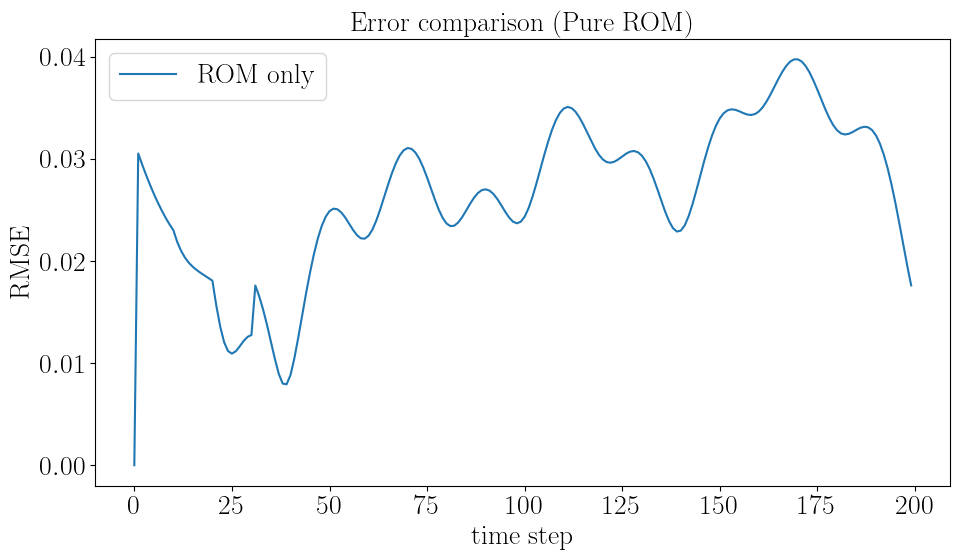

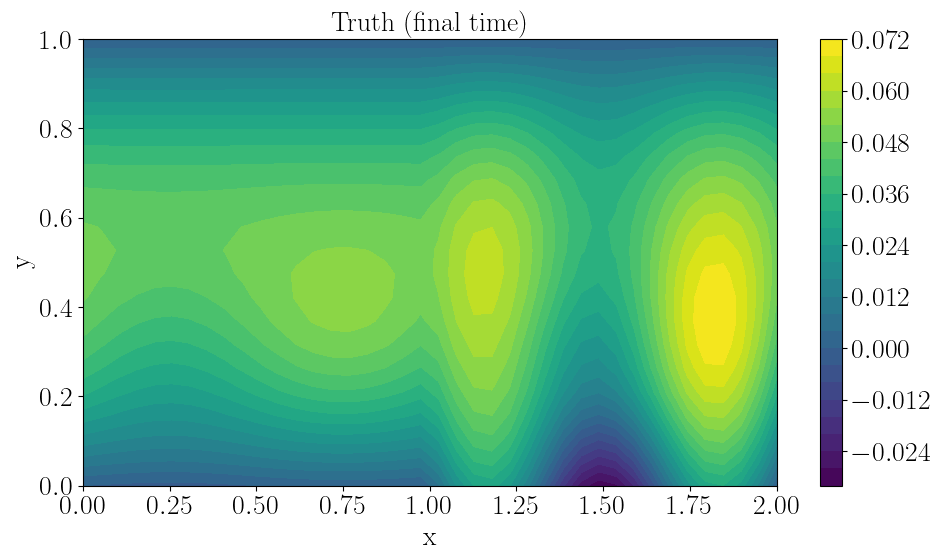

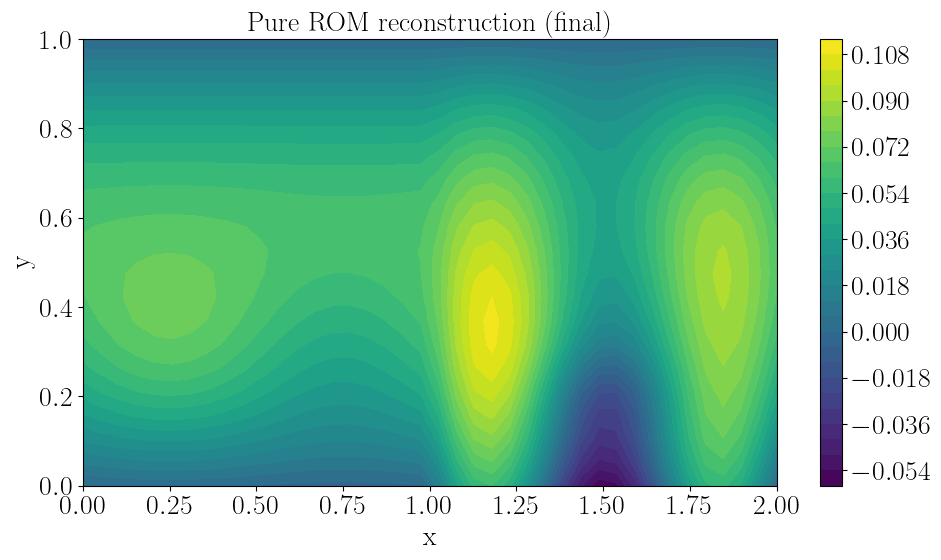

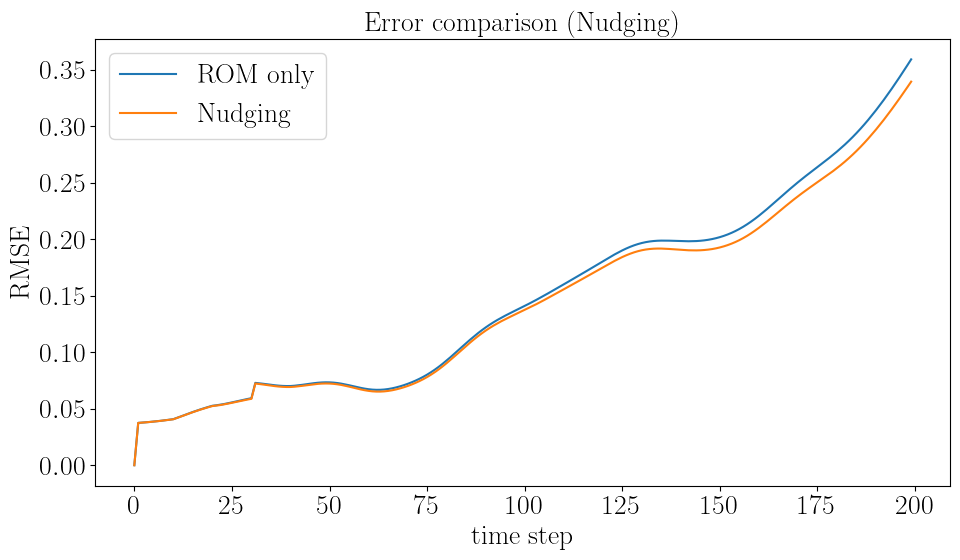

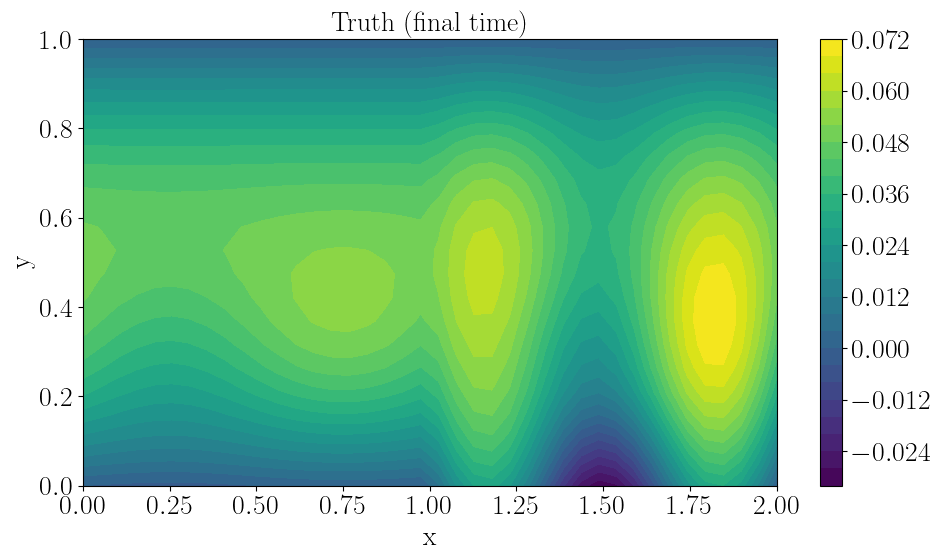

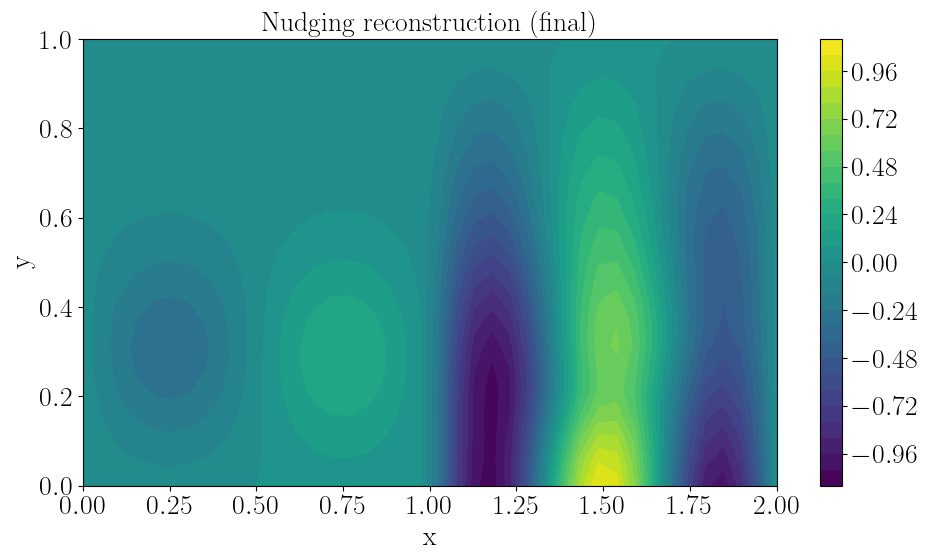

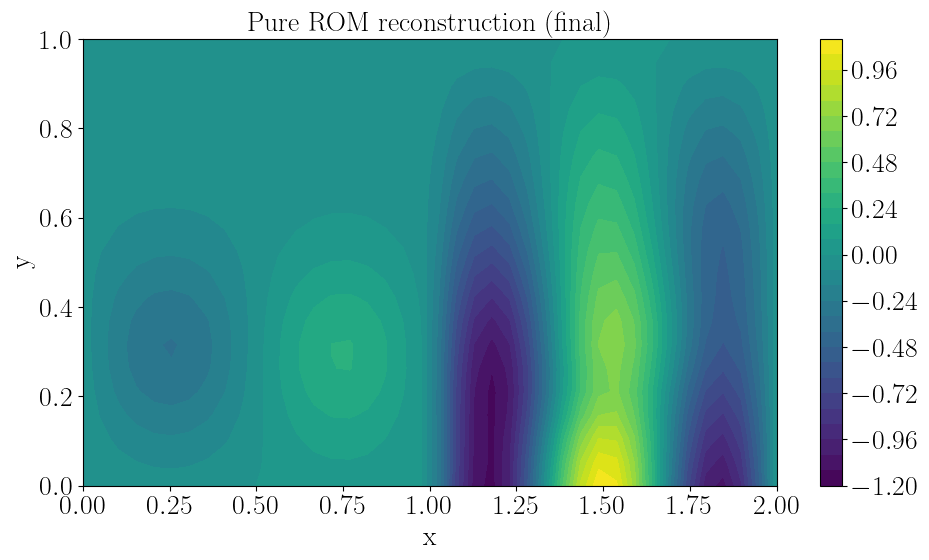

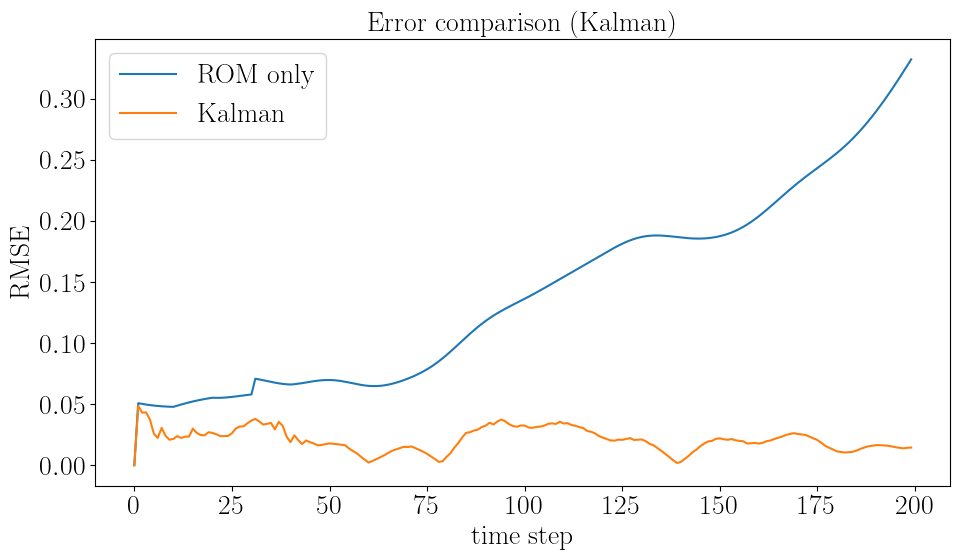

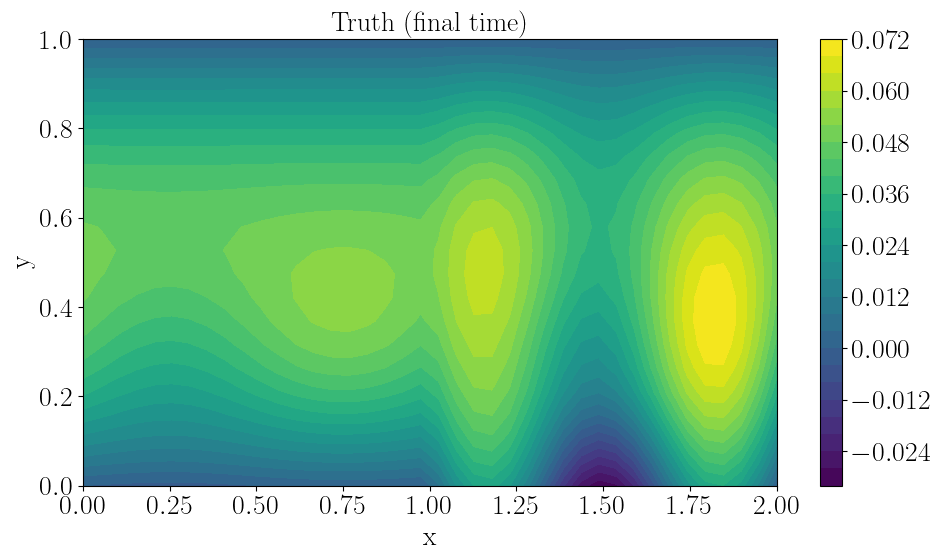

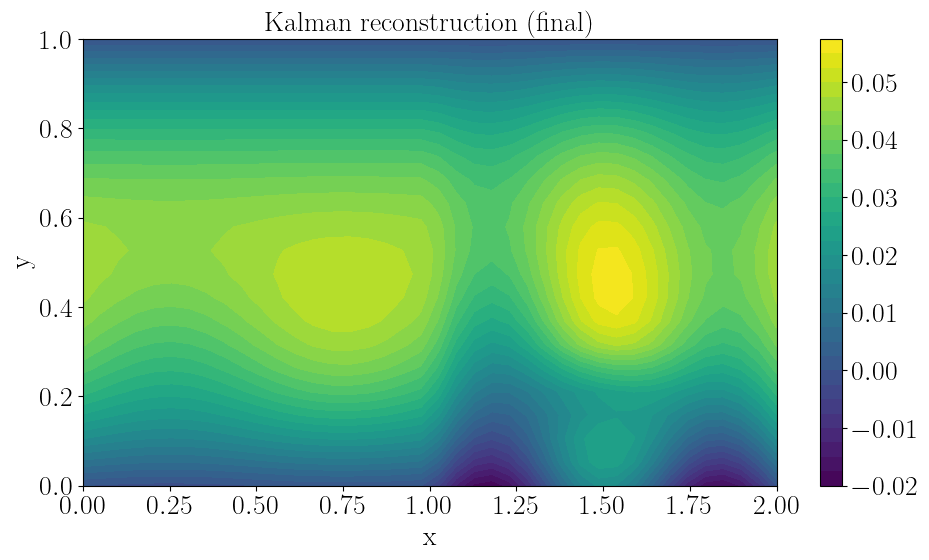

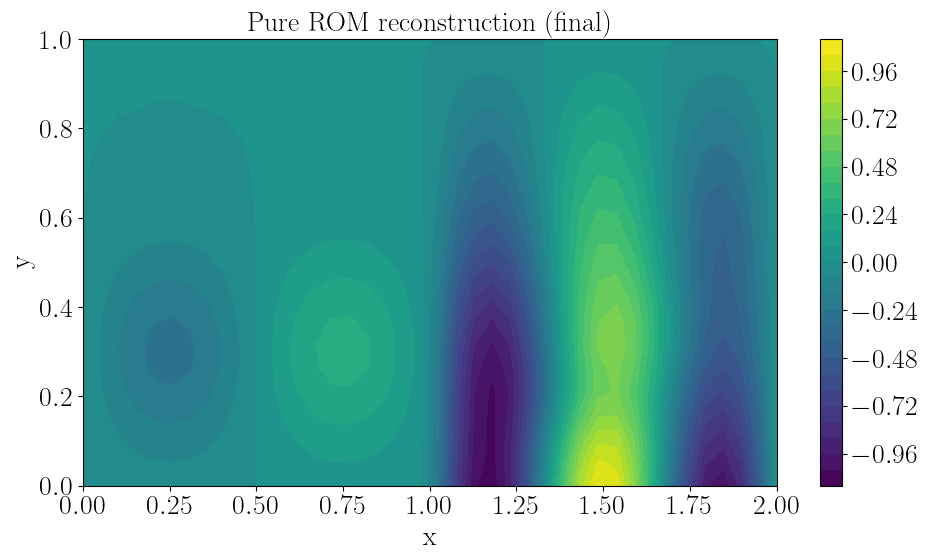

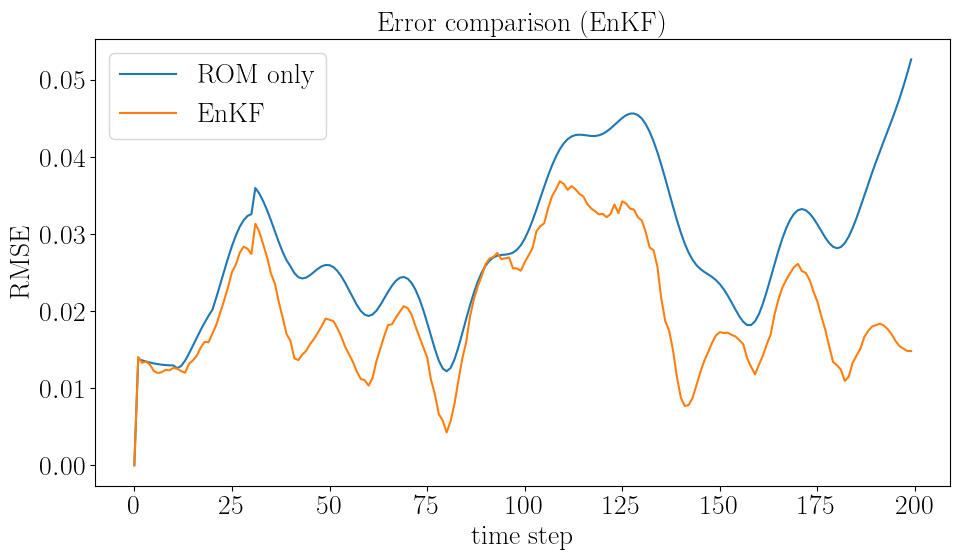

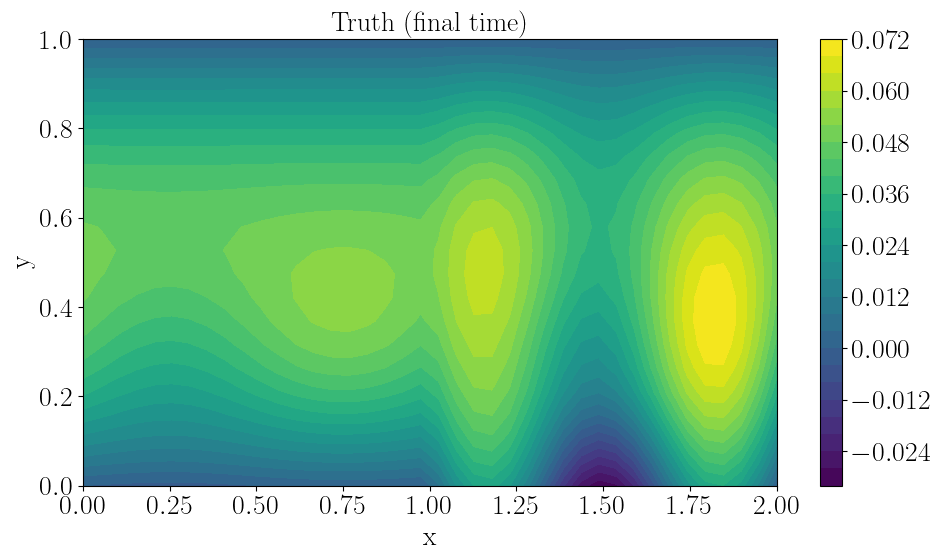

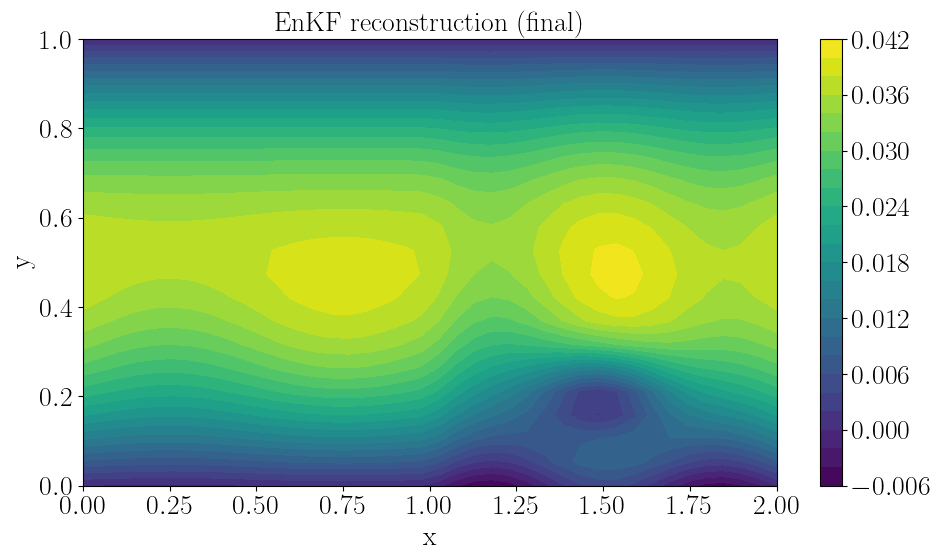

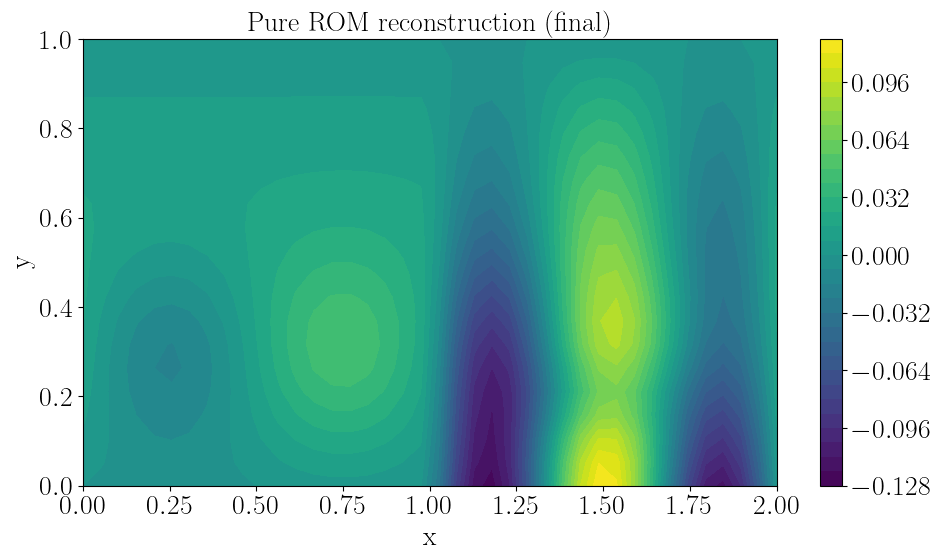

In [31]:
# ============================
# 7) Example runs
# ============================

# 1) Pure ROM (no DA)
_ = run_sequential_DA(method="none",
                      r0_perturb=0.5)

# 2) Nudging
_ = run_sequential_DA(method="nudging",
                      gamma=0.1,
                      obs_noise_std=0.05,
                      r0_perturb=0.5)

# 3) Kalman Filter
_ = run_sequential_DA(method="kalman",
                      b_std=1e-3,
                      r_std=0.05,
                      obs_noise_std=0.05,
                      r0_perturb=0.5)

# 4) Ensemble Kalman Filter
_ = run_sequential_DA(method="enkf",
                      n_ens=30,
                      b_std=1e-3,
                      r_std=0.05,
                      obs_noise_std=0.05,
                      r0_perturb=0.5)


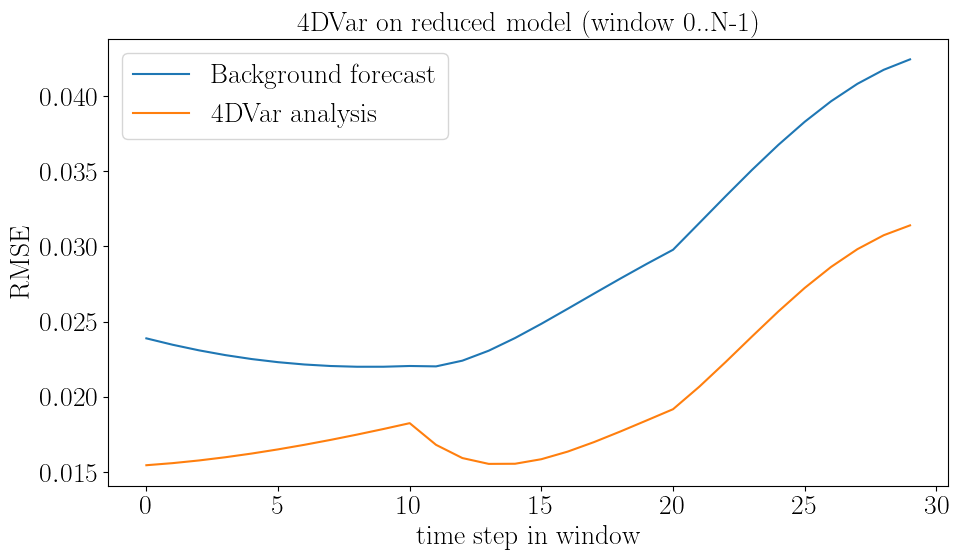

In [32]:
# ============================
# 8) 4DVar on a short window
# ============================

# Choose a window [0, N_win)
N_win = 30

# Truth reduced and observations over the window
r_win_truth = r_true[:, :N_win]                  # (4, N_win)
y_win_truth = H_tilde @ r_win_truth             # (n_sensors, N_win)
obs_noise_std = 0.05
y_win_obs = y_win_truth + obs_noise_std * np.random.randn(n_sensors, N_win)

# Background guess for r0 (wrong initial condition)
r0_b = r_true[:, 0] + 0.5 * np.random.randn(4)

var4d = Var4DAssimilator(F_model, H_tilde,
                         b_std=0.2,
                         r_std=obs_noise_std,
                         window_size=N_win)

r0_opt, traj_opt = var4d.assimilate(r0_b, y_win_obs)

# Compare trajectories
err_b = []
err_opt = []
for k in range(N_win):
    # background forecast (without DA)
    r_bk = np.linalg.matrix_power(F_model, k) @ r0_b
    s_bk = reconstruct_field(r_bk)
    s_optk = reconstruct_field(traj_opt[k])
    s_truek = reconstruct_field(r_win_truth[:, k])

    err_b.append(rmse(s_bk, s_truek))
    err_opt.append(rmse(s_optk, s_truek))

plt.figure(figsize=(10,6))
plt.plot(err_b, label="Background forecast")
plt.plot(err_opt, label="4DVar analysis")
plt.xlabel("time step in window")
plt.ylabel("RMSE")
plt.title("4DVar on reduced model (window 0..N-1)")
plt.legend()
plt.tight_layout()
plt.show()
